<a href="https://colab.research.google.com/github/barco8336-star/Inteligencia-de-Negocios/blob/main/Caso_ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARIMA paso a paso

In [ ]:
pip uninstall numpy -y

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [ ]:
pip install numpy==1.26.4 #original version 2.3.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 45.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
pip install opencv-python-headless==4.11.0.0  # A version that still supports numpy 1.x

ERROR: Ignored the following yanked versions: 3.4.11.39, 3.4.11.41, 4.4.0.40, 4.4.0.42, 4.4.0.44, 4.5.5.62, 4.7.0.68, 4.8.0.74
ERROR: Could not find a version that satisfies the requirement opencv-python-headless==4.11.0.0 (from versions: 3.4.10.37, 3.4.11.43, 3.4.11.45, 3.4.13.47, 3.4.15.55, 3.4.16.59, 3.4.17.61, 3.4.17.63, 3.4.18.65, 4.3.0.38, 4.4.0.46, 4.5.1.48, 4.5.3.56, 4.5.4.58, 4.5.4.60, 4.5.5.64, 4.6.0.66, 4.7.0.72, 4.8.0.76, 4.8.1.78, 4.9.0.80, 4.10.0.82, 4.10.0.84, 4.11.0.86, 4.12.0.88)
ERROR: No matching distribution found for opencv-python-headless==4.11.0.0


In [ ]:
pip install thinc==8.2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 918.3/918.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 33.6 MB/s eta 0:00:00
  Attempting uninstall: blis
    Found existing installation: blis 1.3.0
    Uninstalling blis-1.3.0:
      Successfully uninstalled blis-1.3.0
  Attempting uninstall: thinc
    Found existing installation: thinc 8.3.6
    Uninstalling thinc-8.3.6:
      Successfully uninstalled thinc-8.3.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spacy 3.8.7 requires thinc<8.4.0,>=8.3.4, but you have thinc 8.2.0 which is incompatible.


In [ ]:
pip install pmdarima

In [ ]:
import pmdarima as pm

In [ ]:
import numpy
print(numpy.__version__)

1.26.4


In [ ]:
import pmdarima
print(pmdarima.__version__)

2.0.4


Ya que arreglamos las dependencias de las librerias podemos isntalar las de siempre

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
#1. Leer data
df = sm.datasets.macrodata.load_pandas().data
df.tail()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19
202,2009.0,3.0,12990.341,9256.0,1486.398,1044.088,10040.6,216.385,1673.9,0.12,9.6,308.013,3.56,-3.44


In [ ]:
#2. Convertir el anio y trimestre en formato fecha
df['year'] = df['year'].astype(int)
df['quarter'] = df['quarter'].astype(int)
df.head(2)

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74


In [ ]:
#3. Cambiar el formato de la fecha a datetime y volverlo el indice de la tabla
df['date'] = pd.to_datetime(df['year'].astype(str) + 'Q' + df['quarter'].astype(str))
df = df.set_index('date')

/tmp/ipython-input-306120925.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['year'].astype(str) + 'Q' + df['quarter'].astype(str))


In [ ]:
df.head(2)

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
date,,,,,,,,,,,,,,
1959-01-01,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1959-04-01,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74


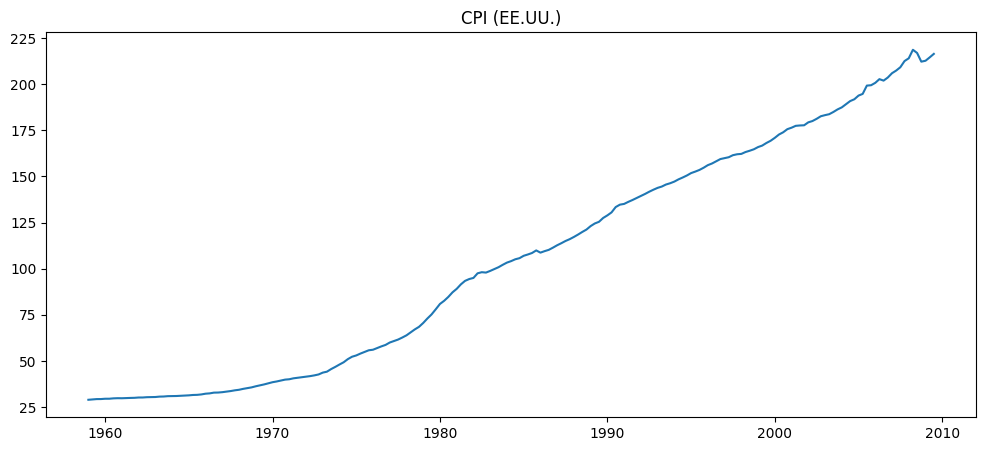

In [ ]:
#3. Grafica de la variable a predecir
plt.figure(figsize=(12,5))
plt.plot(df['cpi'])
plt.title('CPI (EE.UU.)')
plt.show()

In [ ]:
#4. Seleccionar variable
var = df["cpi"]

In [ ]:
#5. Separa test y train
# Usar 80% para train y 20% para test
split_point = int(len(var) * 0.8)
train = var[:split_point]
test = var[split_point:]

# Arima paso a paso

In [ ]:
#6. Verificar si es estacionaria
result = adfuller(train)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] < 0.05:
    print("Serie estacionaria")
else:
    print("Serie no estacionaria")

ADF Statistic: 0.41806147239480185
p-value: 0.9821579539066997
Serie no estacionaria


In [ ]:
#7. Diferenciar serie
dif = train.diff().dropna()
dif.head(2)

,cpi
date,
1959-04-01,0.17
1959-07-01,0.20


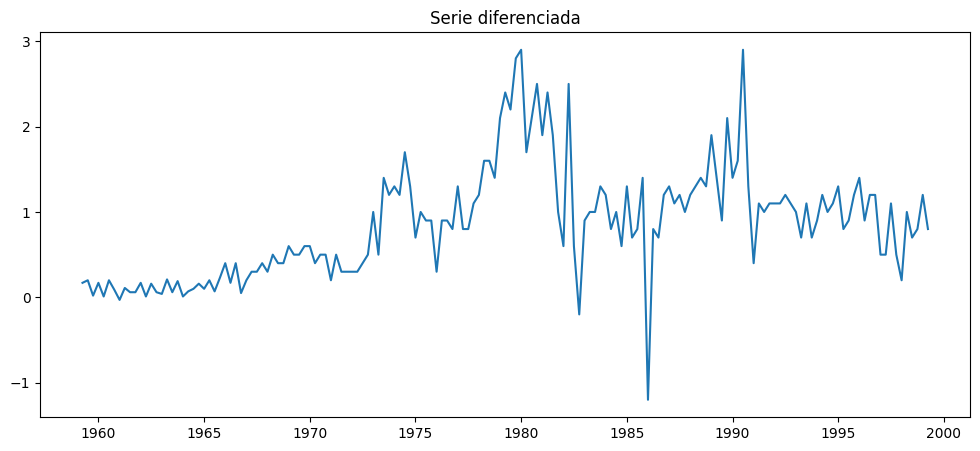

In [ ]:
#8. Graficar la serie diferenciada
plt.figure(figsize=(12,5))
plt.plot(dif)
plt.title('Serie diferenciada')
plt.show()

In [ ]:
#9. Verificar nuevamente si la nueva serie de tiempo es estacionaria
result = adfuller(dif)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] < 0.05:
    print("Serie estacionaria")
else:
    print("Serie no estacionaria")

ADF Statistic: -2.3807996592056733
p-value: 0.14722905243685708
Serie no estacionaria


In [ ]:
#Diferenciar por segunda vez
dif2 = dif.diff().dropna()
dif2.head(2)

,cpi
date,
1959-07-01,0.03
1959-10-01,-0.18


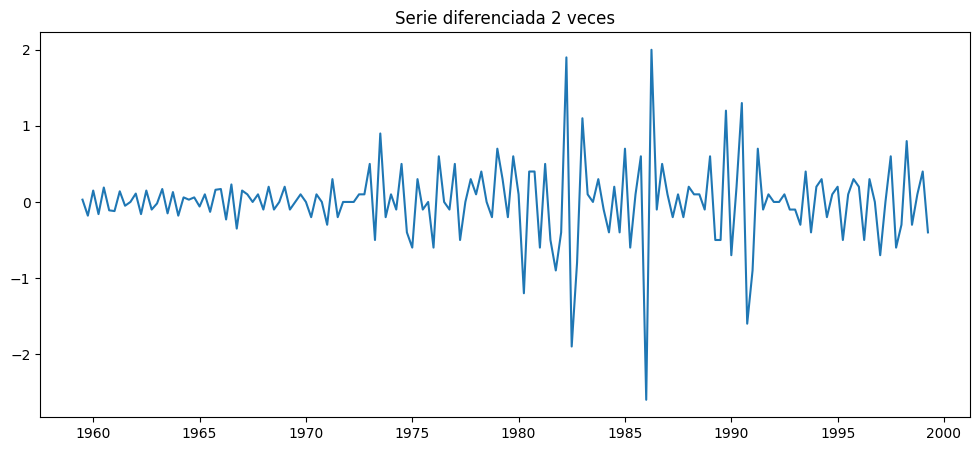

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(dif2)
plt.title('Serie diferenciada 2 veces')
plt.show()

In [ ]:
# Verificar nuevamente
result = adfuller(dif2)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] < 0.05:
    print("Serie estacionaria")
else:
    print("Serie no estacionaria")

ADF Statistic: -17.0763375014734
p-value: 7.76198323958897e-30
Serie estacionaria


In [ ]:
#Tuvimos que diferenciar 2 veces para que la serie sea estacionaria por lo que nuestro parametro d para la serie es 2
d = 2

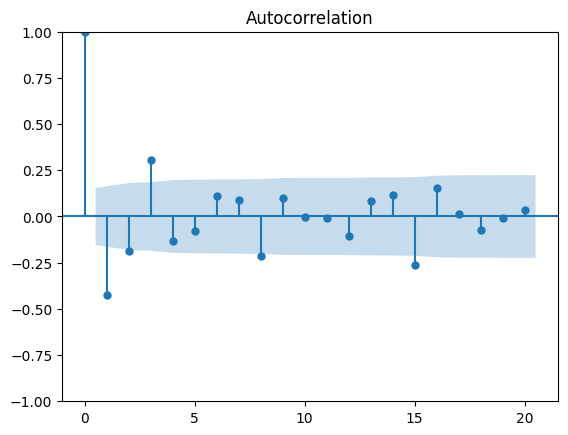

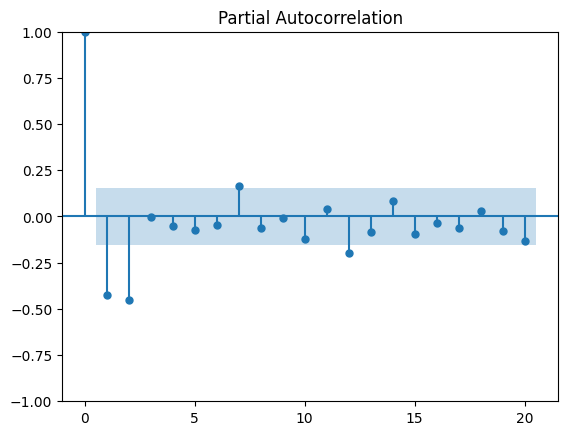

In [ ]:
plot_acf(dif2, lags=20)
plot_pacf(dif2, lags=20)
plt.show()



*   La PACF corta bruscamente despues del lag 2, se sugiere un componente AR ⇒ p = 2.
*   La ACF corta despues del lag 1, se sugiere un componente MA ⇒ q = 1.




In [ ]:
p=2
q=1

In [ ]:
model_manual = ARIMA(train, order=(p, d, q))
result_manual = model_manual.fit()
print(result_manual.summary())

                               SARIMAX Results                                
Dep. Variable:                    cpi   No. Observations:                  162
Model:                 ARIMA(2, 2, 1)   Log Likelihood                 -89.058
Date:                Sat, 02 Aug 2025   AIC                            186.117
Time:                        22:51:19   BIC                            198.417
Sample:                    01-01-1959   HQIC                           191.111
                         - 04-01-1999                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6118      0.108     -5.649      0.000      -0.824      -0.400
ar.L2         -0.4437      0.054     -8.153      0.000      -0.550      -0.337
ma.L1         -0.0051      0.129     -0.040      0.9

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


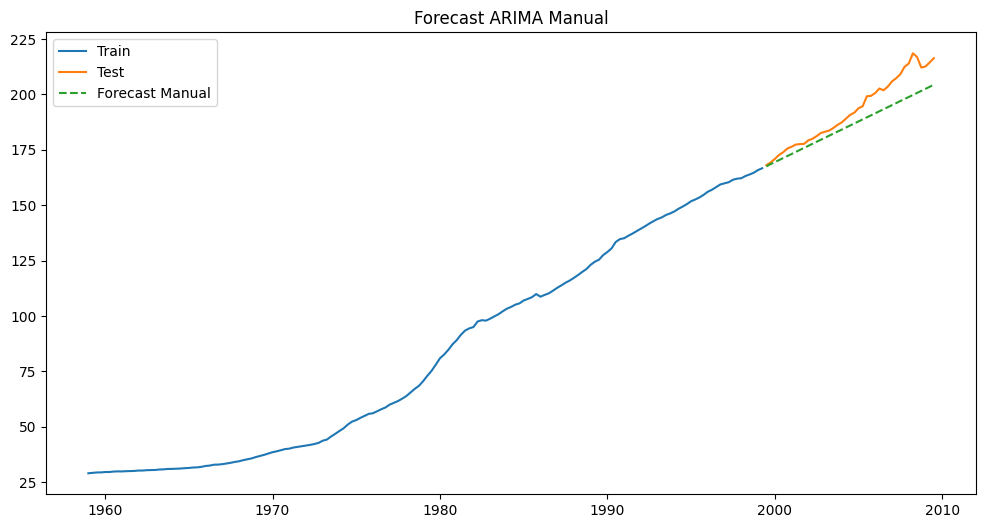

In [ ]:
forecast_manual = result_manual.forecast(steps=len(test))


plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast_manual, label='Forecast Manual', linestyle='--')

plt.legend()
plt.title('Forecast ARIMA Manual')
plt.show()

In [ ]:
rmse = np.sqrt(mean_squared_error(test, forecast_manual))
print(f'RMSE: {rmse:.2f}')

RMSE: 8.11


In [ ]:
mae = mean_absolute_error(test, forecast_manual)
print(f'MAE: {mae:.2f}')

MAE: 6.58


In [ ]:
#Modelo automatico
stepwise_model = pm.auto_arima(train, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)

# Summary
print(stepwise_model.summary())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=189.567, Time=0.26 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=249.890, Time=0.04 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=219.778, Time=0.06 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=194.999, Time=0.07 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,2,0)(0,0,0)[0]             : AIC=247.900, Time=0.04 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=193.394, Time=0.18 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(3,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.58 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=184.117, Time=0.05 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=217.810, Time=0.04 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,2,0)(0,0,0)[0]             : AIC=186.117, Time=0.23 sec
 ARIMA(2,2,1)(0,0,0)[0]             : AIC=186.117, Time=0.08 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=194.882, Time=0.07 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,2,1)(0,0,0)[0]             : AIC=185.207, Time=0.25 sec

Best model:  ARIMA(2,2,0)(0,0,0)[0]          
Total fit time: 2.465 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  162
Model:               SARIMAX(2, 2, 0)   Log Likelihood                 -89.059
Date:                Sat, 02 Aug 2025   AIC                            184.117
Time:                        22:51:41   BIC                            193.343
Sample:                    01-01-1959   HQIC                           187.863
                         - 04-01-1999                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6159      0.043    -14.410      0.000      -0.700  

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


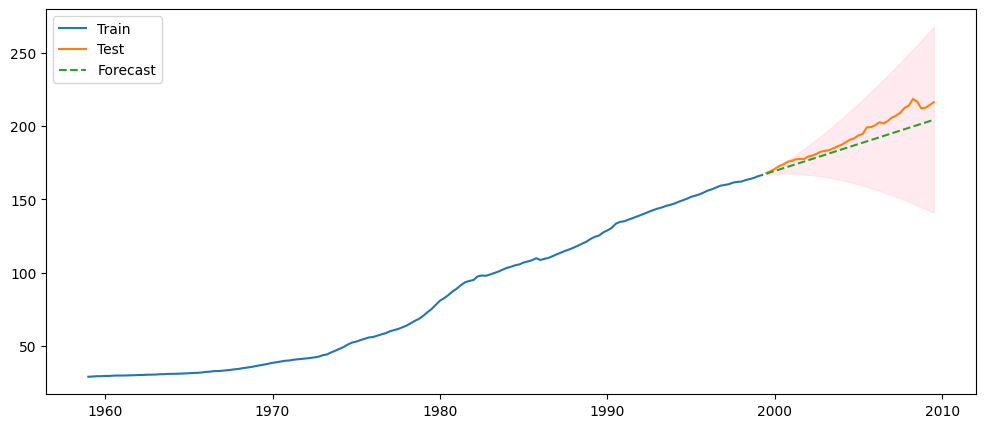

In [ ]:
# Forecast
n_periods = 41
forecast, conf_int = stepwise_model.predict(n_periods=n_periods, return_conf_int=True)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast, label='Forecast', linestyle='--')
plt.fill_between(test.index, conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3)
plt.legend()
plt.show()

In [ ]:
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f'RMSE: {rmse:.2f}')

RMSE: 8.10


In [ ]:
mae = mean_absolute_error(test, forecast)
print(f'MAE: {mae:.2f}')

MAE: 6.57
